# Statistical Comparison

##1

Basic Statistics for Amount:
count     10100.000000
mean       6708.565791
std       12908.218853
min          50.000000
25%        2663.020000
50%        5110.975000
75%        7804.827500
max      796424.000000
Name: Amount, dtype: float64

Transaction Type Distribution:
Transaction Type
WIRE                 0.818218
Cash Withdrawal      0.070297
Currency Exchange    0.049703
SEPA                 0.020495
Cash Deposit         0.020495
SWIFT                0.019307
Cash withdrawal      0.001386
Cash deposit         0.000099
Name: proportion, dtype: float64

Currency Distribution:
Currency
CHF    0.202772
USD    0.202376
GBP    0.200594
JPY    0.200198
EUR    0.194059
Name: proportion, dtype: float64

Top 10 Countries:
Country
United States     2868
United Kingdom    2832
Germany           2817
Australia           32
Denmark             31
Lithuania           31
Åland Islands       29
Belgium             27
New Zealand         27
Bouvet Island       26
Name: count, dtype: int64

Suspic

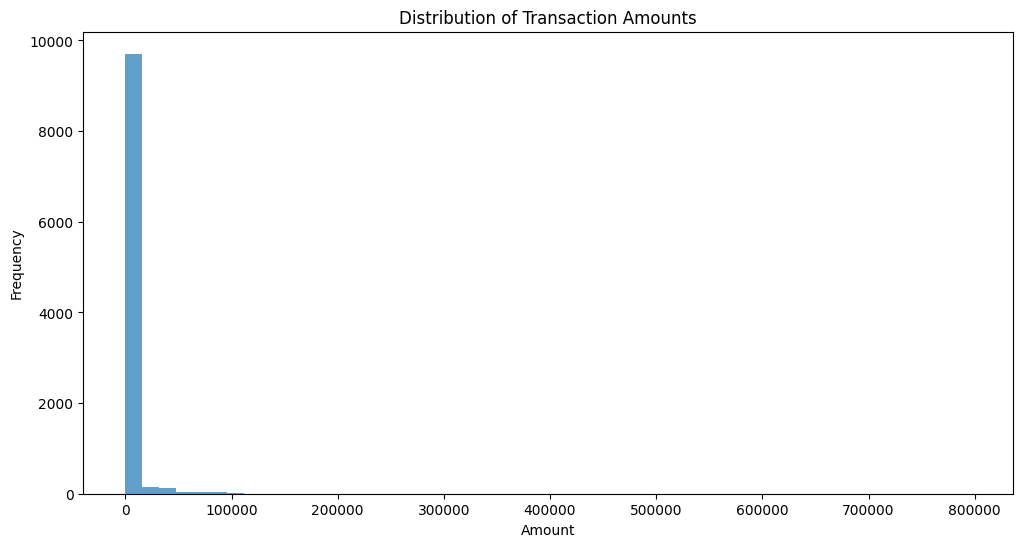

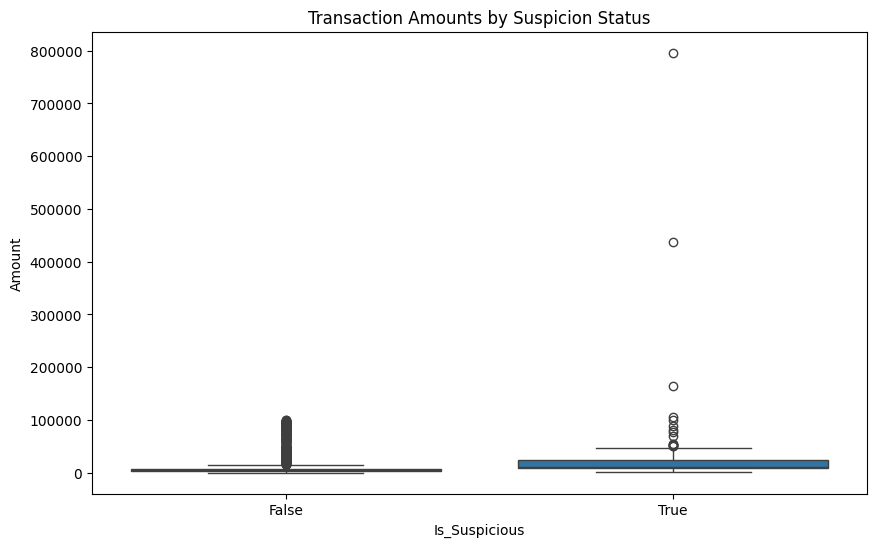

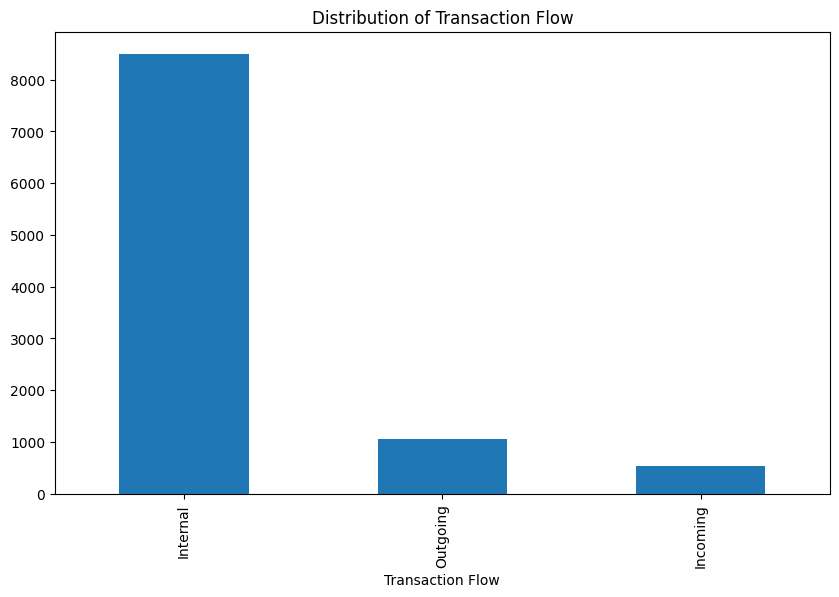

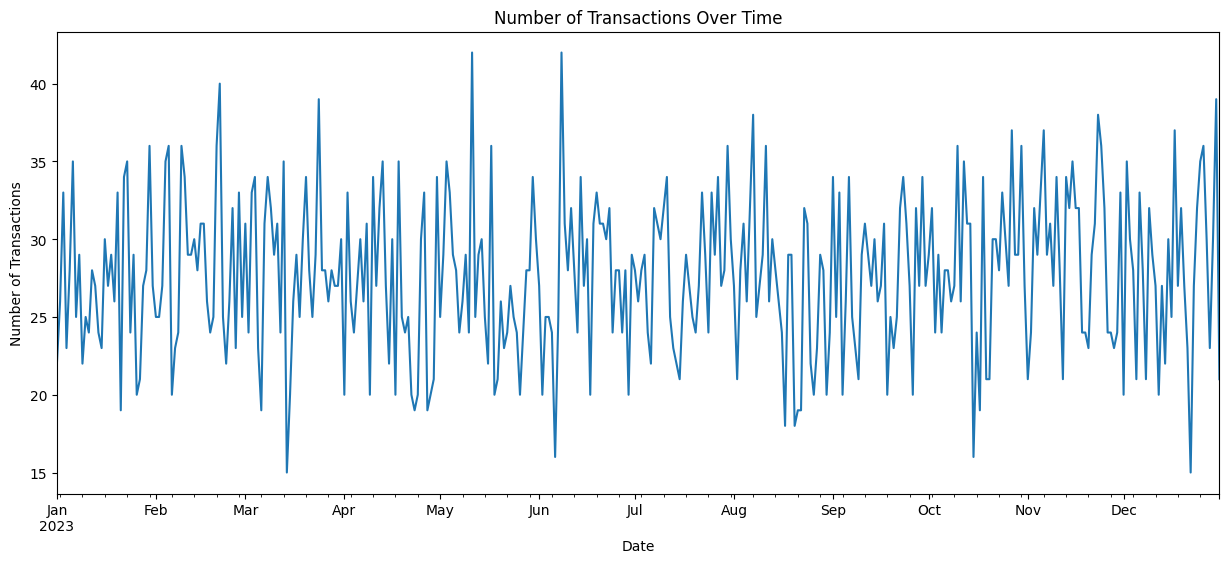


High-Risk Country Statistics:
Total transactions from high-risk countries: 0
Suspicious transactions from high-risk countries: 0

Transaction Amount Ranges:
Amount
0-10k       9608
10k-50k      383
50k-100k     105
100k+          4
Name: count, dtype: int64

Suspicious Transactions by Amount Range:
Is_Suspicious  False  True 
Amount                     
0-10k           9561     47
10k-50k          344     39
50k-100k          95     10
100k+              0      4

Transaction Type by Suspicion Status:
Is_Suspicious      False  True 
Transaction Type               
Cash Deposit         205      2
Cash Withdrawal      710      0
Cash deposit           0      1
Cash withdrawal        0     14
Currency Exchange    500      2
SEPA                 207      0
SWIFT                195      0
WIRE                8183     81


<Figure size 1200x600 with 0 Axes>

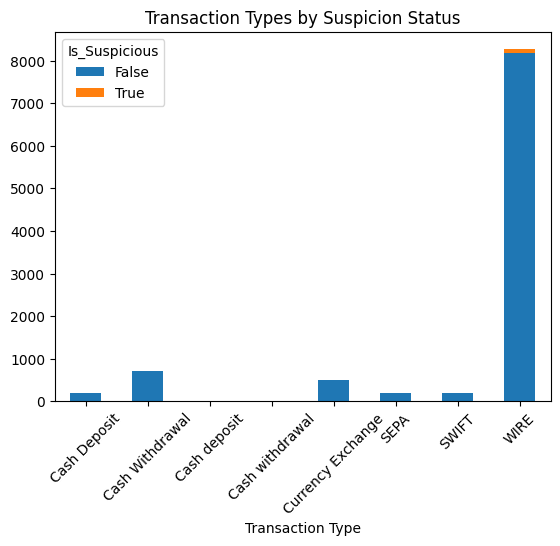


Currency Usage in Suspicious Transactions:
Is_Suspicious  False  True 
Currency                   
CHF             2040      8
EUR             1948     12
GBP             1998     28
JPY             1995     27
USD             2019     25


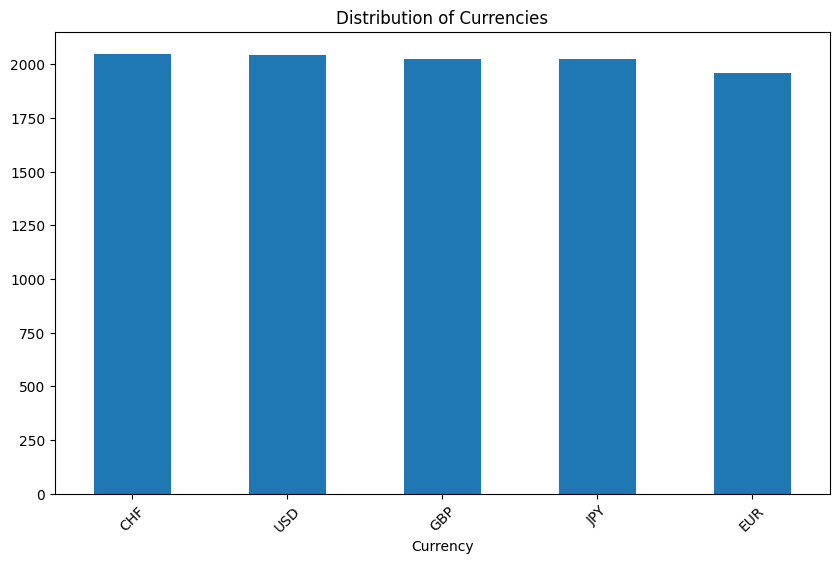

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from datetime import datetime

# Load the synthetic data
synthetic_data = pd.read_csv('synthetic_transactions_structured_100_all.csv')

# 1. Basic Statistics
print("Basic Statistics for Amount:")
print(synthetic_data['Amount'].describe())

# 2. Transaction Analysis
print("\nTransaction Type Distribution:")
print(synthetic_data['Transaction Type'].value_counts(normalize=True))

print("\nCurrency Distribution:")
print(synthetic_data['Currency'].value_counts(normalize=True))

print("\nTop 10 Countries:")
print(synthetic_data['Country'].value_counts().head(10))

# 3. Suspicious Transaction Analysis
suspicious_ratio = synthetic_data['Is_Suspicious'].mean()
print(f"\nSuspicious Transaction Ratio: {suspicious_ratio:.2%}")

# Average amount by suspicion status
print("\nAverage Amount by Suspicion Status:")
print(synthetic_data.groupby('Is_Suspicious')['Amount'].mean())

# Distribution of Suspicion Categories
print("\nDistribution of Suspicion Categories:")
print(synthetic_data['Suspicion Category'].value_counts(normalize=True))

# 4. Visualizations
plt.figure(figsize=(12, 6))
plt.hist(synthetic_data['Amount'], bins=50, alpha=0.7)
plt.title('Distribution of Transaction Amounts')
plt.xlabel('Amount')
plt.ylabel('Frequency')
plt.show()

# Box plot of amounts by suspicion status
plt.figure(figsize=(10, 6))
sns.boxplot(x='Is_Suspicious', y='Amount', data=synthetic_data)
plt.title('Transaction Amounts by Suspicion Status')
plt.show()

# Transaction flow analysis
plt.figure(figsize=(10, 6))
synthetic_data['Transaction Flow'].value_counts().plot(kind='bar')
plt.title('Distribution of Transaction Flow')
plt.show()

# 5. Time Series Analysis
# Convert Date to datetime
synthetic_data['Date'] = pd.to_datetime(synthetic_data['Date'])

# Transaction count over time
plt.figure(figsize=(15, 6))
synthetic_data.groupby('Date').size().plot()
plt.title('Number of Transactions Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Transactions')
plt.show()

# 6. High-Risk Analysis
high_risk_countries = ['Cayman Islands', 'British Virgin Islands', 'Panama']
high_risk_transactions = synthetic_data[synthetic_data['Country'].isin(high_risk_countries)]

print("\nHigh-Risk Country Statistics:")
print(f"Total transactions from high-risk countries: {len(high_risk_transactions)}")
print(f"Suspicious transactions from high-risk countries: {len(high_risk_transactions[high_risk_transactions['Is_Suspicious']])}")

# 7. Amount Range Analysis
amount_ranges = pd.cut(synthetic_data['Amount'],
                      bins=[0, 10000, 50000, 100000, float('inf')],
                      labels=['0-10k', '10k-50k', '50k-100k', '100k+'])
print("\nTransaction Amount Ranges:")
print(amount_ranges.value_counts())

# Suspicious transactions by amount range
print("\nSuspicious Transactions by Amount Range:")
suspicious_by_range = pd.crosstab(amount_ranges, synthetic_data['Is_Suspicious'])
print(suspicious_by_range)

# 8. Transaction Type Analysis
print("\nTransaction Type by Suspicion Status:")
print(pd.crosstab(synthetic_data['Transaction Type'], synthetic_data['Is_Suspicious']))

# Visualization of suspicious transactions by transaction type
plt.figure(figsize=(12, 6))
suspicious_by_type = pd.crosstab(synthetic_data['Transaction Type'], synthetic_data['Is_Suspicious'])
suspicious_by_type.plot(kind='bar', stacked=True)
plt.title('Transaction Types by Suspicion Status')
plt.xticks(rotation=45)
plt.show()

# 9. Currency Analysis
print("\nCurrency Usage in Suspicious Transactions:")
currency_suspicious = pd.crosstab(synthetic_data['Currency'], synthetic_data['Is_Suspicious'])
print(currency_suspicious)

# Plot currency distribution
plt.figure(figsize=(10, 6))
synthetic_data['Currency'].value_counts().plot(kind='bar')
plt.title('Distribution of Currencies')
plt.xticks(rotation=45)
plt.show()

##2

### DATA QUALITY REPORT ###

1. BASIC DATA QUALITY METRICS
--------------------------------------------------
Total Records: 10100
Missing Values:
Transaction_id        0
Sender                0
Receiver              0
Amount                0
Currency              0
Country               0
Transaction Type      0
Description           0
Date                  0
Transaction Flow      0
Is_Suspicious         0
Suspicion Category    0
dtype: int64

Duplicate Records: 0

2. TRANSACTION AMOUNT ANALYSIS
--------------------------------------------------

Amount Statistics:
count     10100.000000
mean       6708.565791
std       12908.218853
min          50.000000
25%        2663.020000
50%        5110.975000
75%        7804.827500
max      796424.000000
Name: Amount, dtype: float64


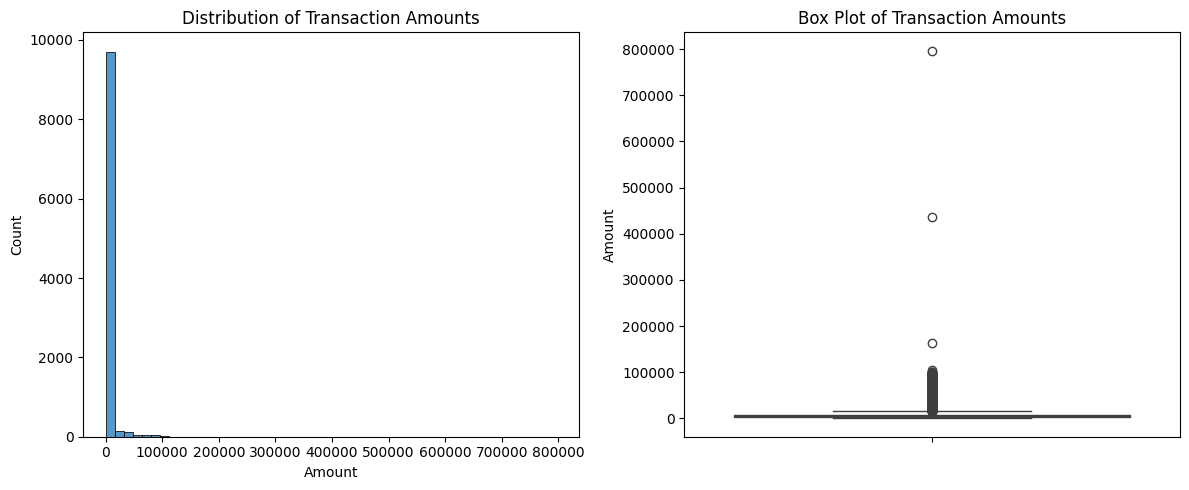


3. SUSPICIOUS TRANSACTION ANALYSIS
--------------------------------------------------
Suspicious Transaction Ratio: 0.99%

Amount Statistics by Suspicion Status:
                 count          mean           std    min       25%  \
Is_Suspicious                                                         
False          10000.0   6445.694449   8863.099662   50.0  2657.265   
True             100.0  32995.700000  91422.958197  350.0  8030.000   

                     50%         75%       max  
Is_Suspicious                                   
False           5068.015   7754.5375   99560.0  
True           10660.000  24560.0000  796424.0  


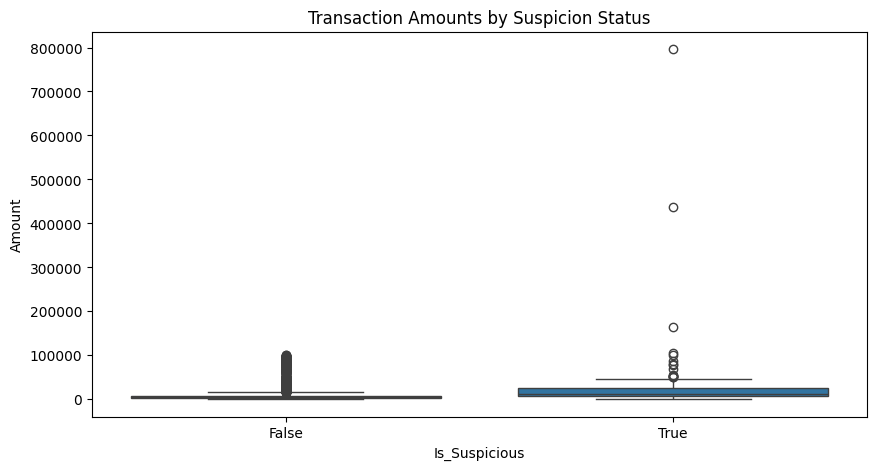


4. CATEGORICAL VARIABLE ANALYSIS
--------------------------------------------------

Currency Distribution:
Currency
CHF    0.202772
USD    0.202376
GBP    0.200594
JPY    0.200198
EUR    0.194059
Name: proportion, dtype: float64


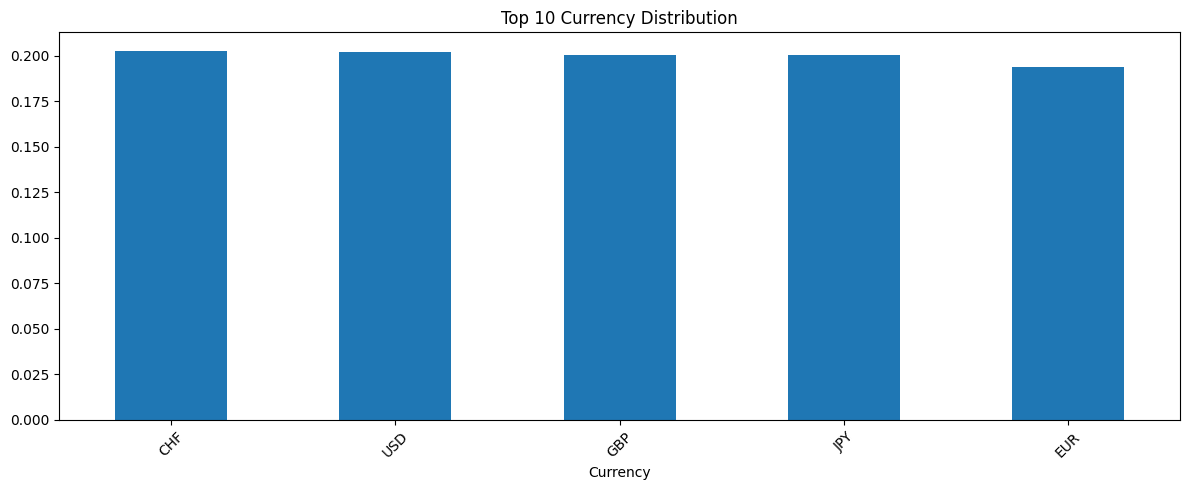


Country Distribution:
Country
United States     0.283960
United Kingdom    0.280396
Germany           0.278911
Australia         0.003168
Denmark           0.003069
Name: proportion, dtype: float64


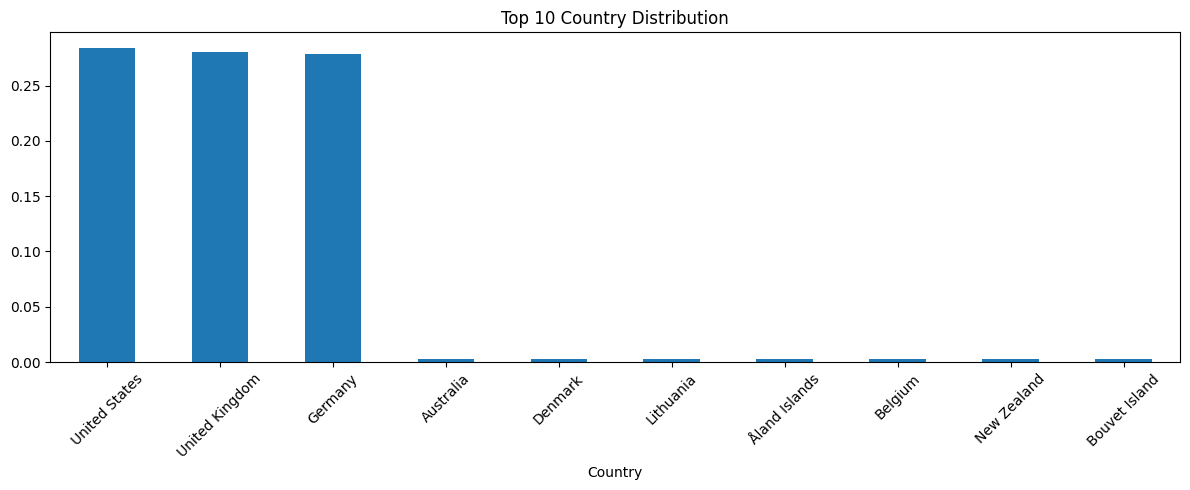


Transaction Type Distribution:
Transaction Type
WIRE                 0.818218
Cash Withdrawal      0.070297
Currency Exchange    0.049703
SEPA                 0.020495
Cash Deposit         0.020495
Name: proportion, dtype: float64


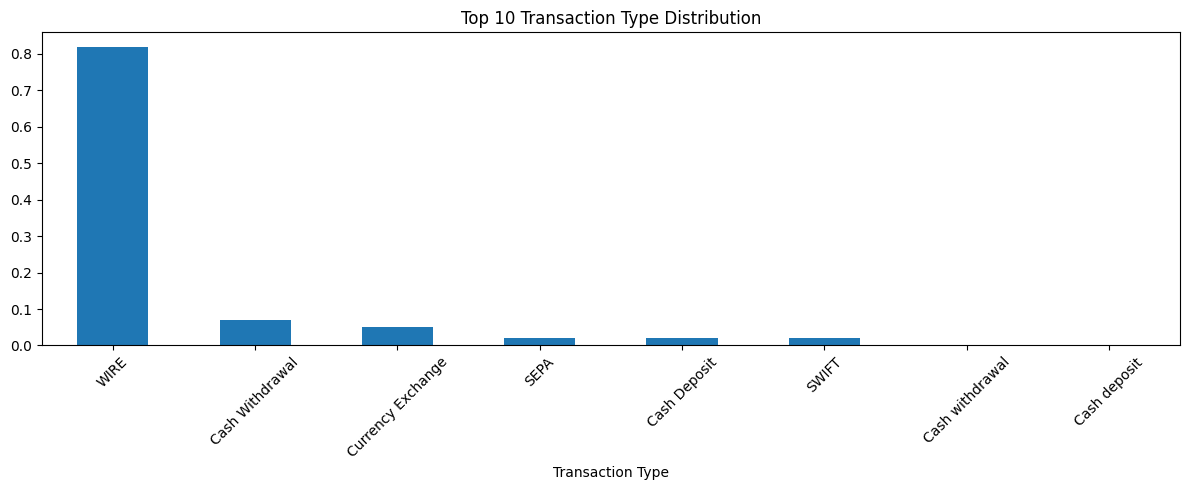


Transaction Flow Distribution:
Transaction Flow
Internal    0.841782
Outgoing    0.105446
Incoming    0.052772
Name: proportion, dtype: float64


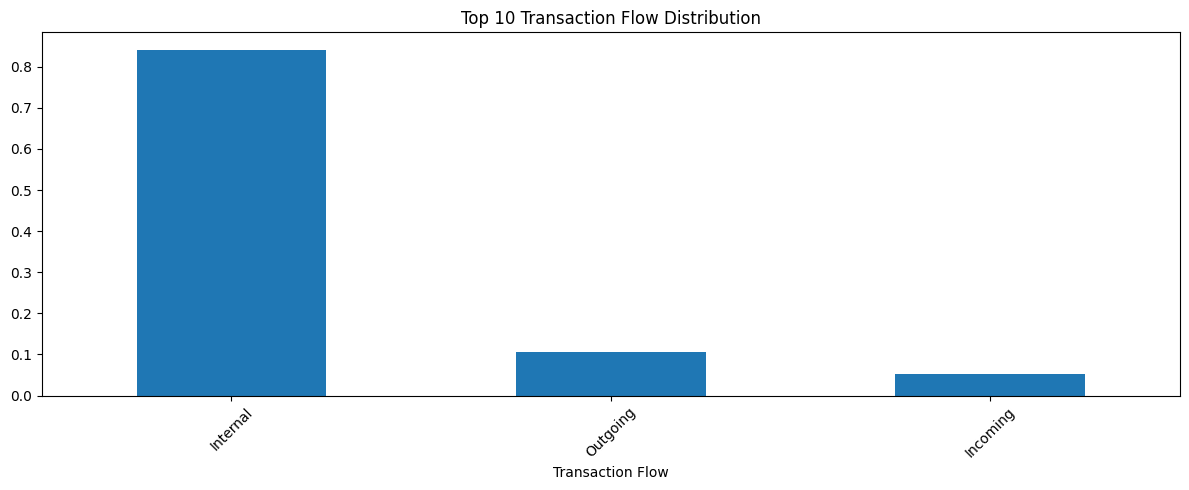


Suspicion Category Distribution:
Suspicion Category
Normal                                  0.990099
Many-to-One Pattern                     0.000990
Repetitive Missing Reference Numbers    0.000990
One-to-Many Pattern                     0.000594
Balanced Flow Analysis                  0.000594
Name: proportion, dtype: float64


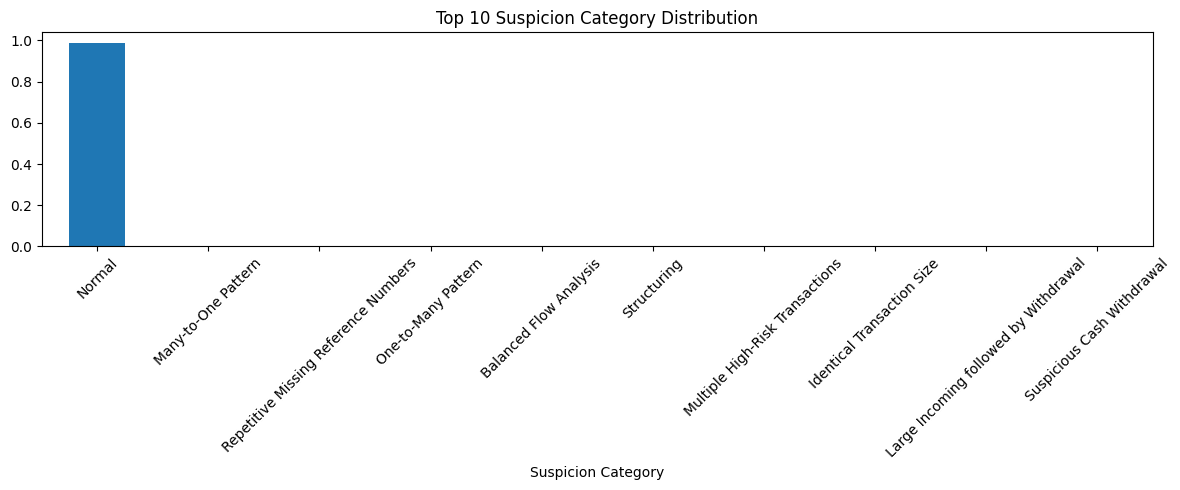


5. TEMPORAL ANALYSIS
--------------------------------------------------


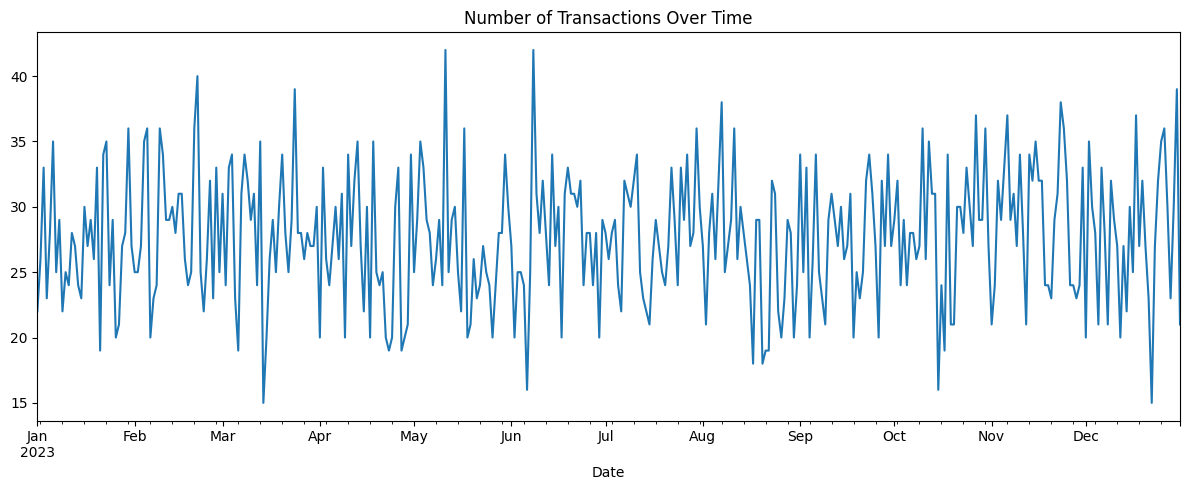


6. PATTERN ANALYSIS
--------------------------------------------------

Currency usage in suspicious transactions:
Is_Suspicious     False     True 
Currency                         
CHF            0.996094  0.003906
EUR            0.993878  0.006122
GBP            0.986180  0.013820
JPY            0.986647  0.013353
USD            0.987769  0.012231

High-risk country transactions: 0
Suspicious transactions in high-risk countries: 0

7. DATA QUALITY SCORES
--------------------------------------------------
Completeness Score: 100.00%
Uniqueness Score: 100.00%
Currency Consistency Score: 100.00%

8. RELATIONSHIP ANALYSIS
--------------------------------------------------


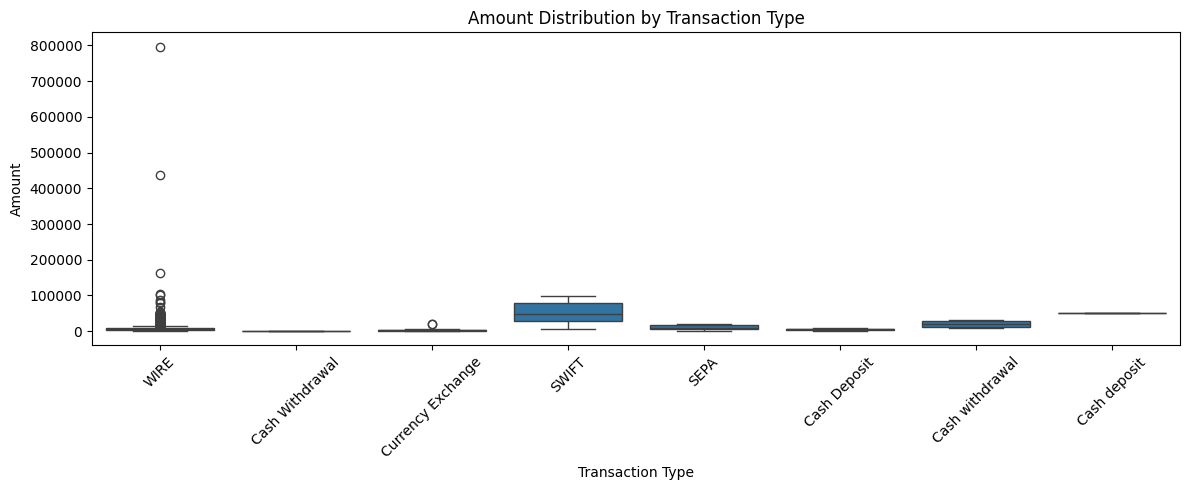


Suspicious patterns by Transaction Flow:
Is_Suspicious        False     True 
Transaction Flow                    
Incoming          0.960600  0.039400
Internal          0.999765  0.000235
Outgoing          0.927700  0.072300

9. SUMMARY AND RECOMMENDATIONS
--------------------------------------------------

Identified Issues:
No major issues identified


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

def test_synthetic_data(df):
    """
    Comprehensive function to test synthetic transaction data quality
    Parameters:
    df (pandas.DataFrame): The synthetic transaction dataset
    """
    print("### DATA QUALITY REPORT ###\n")

    # 1. Basic Data Quality Checks
    print("1. BASIC DATA QUALITY METRICS")
    print("-" * 50)
    print(f"Total Records: {len(df)}")
    print(f"Missing Values:\n{df.isnull().sum()}")
    print("\nDuplicate Records:", df.duplicated().sum())

    # 2. Statistical Summary of Amount
    print("\n2. TRANSACTION AMOUNT ANALYSIS")
    print("-" * 50)
    amount_stats = df['Amount'].describe()
    print("\nAmount Statistics:")
    print(amount_stats)

    # Visualize Amount Distribution
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    sns.histplot(df['Amount'], bins=50)
    plt.title('Distribution of Transaction Amounts')
    plt.subplot(1, 2, 2)
    sns.boxplot(y=df['Amount'])
    plt.title('Box Plot of Transaction Amounts')
    plt.tight_layout()
    plt.show()

    # 3. Suspicious Transaction Analysis
    print("\n3. SUSPICIOUS TRANSACTION ANALYSIS")
    print("-" * 50)
    suspicious_ratio = df['Is_Suspicious'].mean()
    print(f"Suspicious Transaction Ratio: {suspicious_ratio:.2%}")

    # Amount by Suspicion Status
    print("\nAmount Statistics by Suspicion Status:")
    print(df.groupby('Is_Suspicious')['Amount'].describe())

    # Visualize Amount by Suspicion Status
    plt.figure(figsize=(10, 5))
    sns.boxplot(x='Is_Suspicious', y='Amount', data=df)
    plt.title('Transaction Amounts by Suspicion Status')
    plt.show()

    # 4. Categorical Variable Analysis
    print("\n4. CATEGORICAL VARIABLE ANALYSIS")
    print("-" * 50)

    categorical_cols = ['Currency', 'Country', 'Transaction Type',
                       'Transaction Flow', 'Suspicion Category']

    for col in categorical_cols:
        print(f"\n{col} Distribution:")
        dist = df[col].value_counts(normalize=True)
        print(dist.head())

        # Visualize top 10 categories
        plt.figure(figsize=(12, 5))
        dist.head(10).plot(kind='bar')
        plt.title(f'Top 10 {col} Distribution')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

    # 5. Temporal Analysis
    print("\n5. TEMPORAL ANALYSIS")
    print("-" * 50)

    df['Date'] = pd.to_datetime(df['Date'])

    # Transactions by date
    daily_transactions = df.groupby('Date').size()

    plt.figure(figsize=(12, 5))
    daily_transactions.plot()
    plt.title('Number of Transactions Over Time')
    plt.tight_layout()
    plt.show()

    # 6. Pattern Analysis
    print("\n6. PATTERN ANALYSIS")
    print("-" * 50)

    # Currency usage in suspicious transactions
    currency_suspicious = pd.crosstab(df['Currency'], df['Is_Suspicious'], normalize='index')
    print("\nCurrency usage in suspicious transactions:")
    print(currency_suspicious)

    # High-risk country analysis
    high_risk_countries = ['Cayman Islands', 'British Virgin Islands', 'Panama']
    high_risk_txns = df[df['Country'].isin(high_risk_countries)]
    print(f"\nHigh-risk country transactions: {len(high_risk_txns)}")
    print(f"Suspicious transactions in high-risk countries: "
          f"{len(high_risk_txns[high_risk_txns['Is_Suspicious']])}")

    # 7. Data Quality Scores
    print("\n7. DATA QUALITY SCORES")
    print("-" * 50)

    # Completeness Score
    completeness = 1 - (df.isnull().sum().sum() / (df.shape[0] * df.shape[1]))
    print(f"Completeness Score: {completeness:.2%}")

    # Uniqueness Score (based on duplicate records)
    uniqueness = 1 - (df.duplicated().sum() / len(df))
    print(f"Uniqueness Score: {uniqueness:.2%}")

    # Consistency Score (based on valid currency codes)
    valid_currencies = ['USD', 'EUR', 'GBP', 'CHF', 'JPY']
    currency_consistency = (df['Currency'].isin(valid_currencies).sum() / len(df))
    print(f"Currency Consistency Score: {currency_consistency:.2%}")

    # 8. Relationship Analysis
    print("\n8. RELATIONSHIP ANALYSIS")
    print("-" * 50)

    # Amount vs Transaction Type
    plt.figure(figsize=(12, 5))
    sns.boxplot(x='Transaction Type', y='Amount', data=df)
    plt.xticks(rotation=45)
    plt.title('Amount Distribution by Transaction Type')
    plt.tight_layout()
    plt.show()

    # Suspicious patterns by Transaction Flow
    flow_suspicious = pd.crosstab(df['Transaction Flow'], df['Is_Suspicious'], normalize='index')
    print("\nSuspicious patterns by Transaction Flow:")
    print(flow_suspicious)

    # 9. Summary and Recommendations
    print("\n9. SUMMARY AND RECOMMENDATIONS")
    print("-" * 50)

    # Data quality issues
    issues = []

    if suspicious_ratio > 0.1:
        issues.append("High suspicious transaction ratio (>10%)")

    if completeness < 0.95:
        issues.append("Low completeness score (<95%)")

    if uniqueness < 0.95:
        issues.append("Low uniqueness score (<95%)")

    if currency_consistency < 0.95:
        issues.append("Low currency consistency score (<95%)")

    if len(df['Transaction Type'].unique()) < 3:
        issues.append("Limited variety in transaction types (<3 types)")

    print("\nIdentified Issues:")
    if issues:
        for issue in issues:
            print(f"- {issue}")
    else:
        print("No major issues identified")

# Load and test the data
df = pd.read_csv('synthetic_transactions_structured_100_all.csv')
test_synthetic_data(df)